In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import joblib
import os

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import spearmanr
from scipy.stats import zscore
from scipy.stats import mannwhitneyu

from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

# Random Surivial Forests

- an ensemble of survival trees
- survival = survival event + time object
- uses the log-rank test for feature & threshold selection

## Preparing Data for Fitting

In [2]:
# load pre-processed datasets
train_data    = pd.read_csv("../../datasets/csv_files/ml_datasets/train_data.csv")
test_data_one   = pd.read_csv("../../datasets/csv_files/ml_datasets/test_data_one.csv")
test_data_two   = pd.read_csv("../../datasets/csv_files/ml_datasets/test_data_two.csv")
test_data_three = pd.read_csv("../../datasets/csv_files/ml_datasets/test_data_three.csv")

In [3]:
# define X & y for all datasets
X_train = train_data.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
y_train = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

X_test_one = test_data_one.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_one = X_test_one[X_train.columns]
y_test_one = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_one)

X_test_two = test_data_two.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_two = X_test_two[X_train.columns]
y_test_two = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_two)

X_test_three = test_data_three.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_three = X_test_three[X_train.columns]
y_test_three = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_three)

In [4]:
model_path = "../../models/rsf_v2.joblib"
random_state = 20

if os.path.exists(model_path):
    print("Loading saved RSF model...")
    rsf = joblib.load(model_path)
    print("Loaded.")
else:
    print("Training RSF (this may take a few minutes)...")
    rsf = RandomSurvivalForest(
        n_estimators=1000,
        min_samples_split=20,
        min_samples_leaf=30,
        max_features="log2",
        max_depth=20,
        oob_score=True,
        n_jobs=-1,
        random_state=random_state
    )
    rsf.fit(X_train, y_train)
    joblib.dump(rsf, model_path)
    print("Trained and saved.")

Loading saved RSF model...
Loaded.


## Testing

In [5]:
c_index_train = rsf.score(X_train, y_train)
c_index_test_one = rsf.score(X_test_one, y_test_one)
c_index_test_two = rsf.score(X_test_two, y_test_two)
c_index_test_three = rsf.score(X_test_three, y_test_three)

print(f"Train C-index: {c_index_train:.5f}")
print(f"Test 1 C-index: {c_index_test_one:.5f}")
print(f"Test 2 C-index: {c_index_test_two:.5f}")
print(f"Test 3 C-index: {c_index_test_three:.5f}")
print(f"OOB C-index: {rsf.oob_score_:.5f}")

Train C-index: 0.79663
Test 1 C-index: 0.63340
Test 2 C-index: 0.57877
Test 3 C-index: 0.69821
OOB C-index: 0.63935


## Save Model

In [6]:
os.makedirs("../../models", exist_ok=True)
joblib.dump(rsf, "../../models/rsf_v2.joblib")

['../../models/rsf_v2.joblib']

## Permutation Importance

In [7]:
perm_path = "../../models/rsf_perm_importance_v2.csv"

if os.path.exists(perm_path):
    print("Loading cached permutation importance...")
    perm_df = pd.read_csv(perm_path)
else:
    print("Computing permutation importance (n_repeats=5, parallelised — may take several minutes)...")
    result = permutation_importance(
        rsf, X_train, y_train,
        n_repeats=5, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        "gene":             X_train.columns,
        "importance_mean":  result.importances_mean,
        "importance_std":   result.importances_std,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    perm_df.to_csv(perm_path, index=False)
    print("Done. Cached to rsf_perm_importance_v2.csv")

print(f"\nTop 20 features by permutation importance:")
print(perm_df.head(20).to_string(index=False))

Loading cached permutation importance...

Top 20 features by permutation importance:
   gene  importance_mean  importance_std
   SOX4         0.007561        0.006122
RARRES3         0.005464        0.001622
   ACO1         0.005353        0.002273
    HBB         0.004857        0.000331
    CFB         0.004029        0.000773
 FBXL16         0.003698        0.002062
 CYSTM1         0.003587        0.001209
   ARF1         0.002759        0.001951
  S100P         0.002759        0.002559
   SVIP         0.002704        0.000978
  ALDOC         0.002649        0.000917
   FBN1         0.002649        0.000413
  PRDX6         0.002594        0.001126
  ERAP1         0.002428        0.001946
   MICB         0.002428        0.000914
  KLHL5         0.002373        0.001615
  IL17D         0.002318        0.001381
  WASF3         0.002097        0.000689
  AP1M2         0.002097        0.000949
   BST2         0.002042        0.000949


Saved: rsf_permutation_importance.png


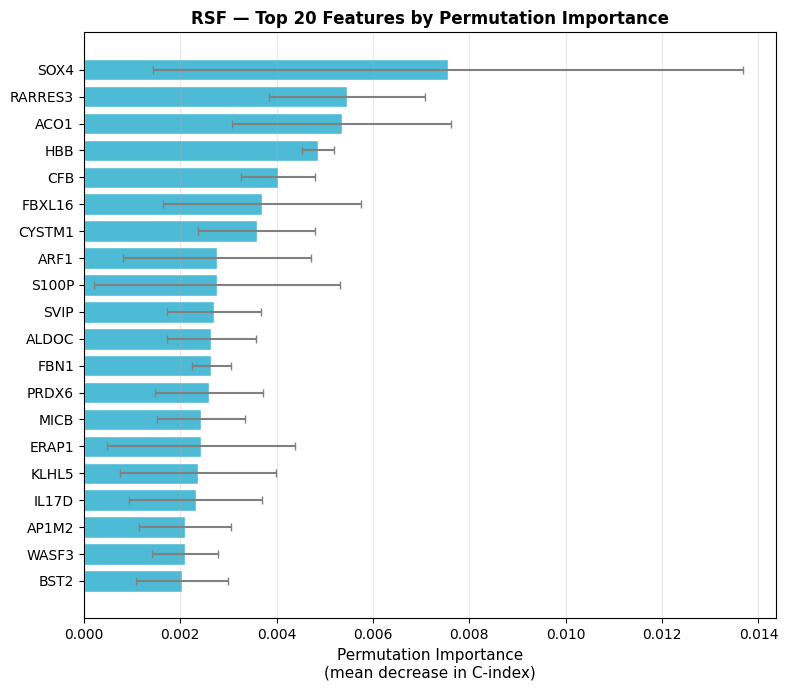

In [8]:
# Bar chart: top 20 genes by permutation importance
top20 = perm_df.head(20).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(top20["gene"], top20["importance_mean"],
               xerr=top20["importance_std"], color="#4DBBD5",
               error_kw=dict(ecolor="grey", capsize=3), edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Permutation Importance\n(mean decrease in C-index)", fontsize=11)
ax.set_title("RSF — Top 20 Features by Permutation Importance", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../../visuals/rsf_permutation_importance.png", dpi=150, bbox_inches="tight")
print("Saved: rsf_permutation_importance.png")
plt.show()

## RSF Gene Signature

In [9]:
# Select signature: top 8 genes with positive importance (aggressive / compact)
sig_df = perm_df[perm_df["importance_mean"] > 0].head(8).copy()
if len(sig_df) < 3:                          # fallback if few positive-importance genes
    sig_df = perm_df.head(8).copy()

sig_genes = sig_df["gene"].tolist()

# Determine direction: Spearman correlation of expression with RSF risk score
rsf_risk_train = rsf.predict(X_train)        # cumulative hazard — higher = higher risk

directions = []
for gene in sig_genes:
    r, p = spearmanr(X_train[gene], rsf_risk_train)
    directions.append({
        "gene":       gene,
        "importance": round(sig_df.loc[sig_df["gene"] == gene, "importance_mean"].values[0], 5),
        "spearman_r": round(r, 4),
        "p_value":    round(p, 4),
        "role":       "danger" if r > 0 else "protective",
    })

sig_genes_df = pd.DataFrame(directions)

# Paper comparison
PAPER_SIGNATURE = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]
in_paper  = [g for g in sig_genes if g in PAPER_SIGNATURE]
not_paper = [g for g in sig_genes if g not in PAPER_SIGNATURE]
missing   = [g for g in PAPER_SIGNATURE if g not in sig_genes]

print("=" * 55)
print(f"  RSF IMMUNE RISK SIGNATURE  ({len(sig_genes)} genes)")
print("=" * 55)
for _, row in sig_genes_df.iterrows():
    marker = "  [paper]" if row["gene"] in PAPER_SIGNATURE else ""
    print(f"  {row['gene']:<12}  imp={row['importance']:.5f}  r={row['spearman_r']:+.3f}  {row['role']}{marker}")

print()
print(f"Paper overlap : {len(in_paper)}/{len(PAPER_SIGNATURE)} — {in_paper}")
print(f"Novel genes   : {not_paper}")
print(f"Paper genes missing: {missing}")

  RSF IMMUNE RISK SIGNATURE  (8 genes)
  SOX4          imp=0.00756  r=+0.321  danger
  RARRES3       imp=0.00546  r=-0.443  protective  [paper]
  ACO1          imp=0.00535  r=-0.277  protective  [paper]
  HBB           imp=0.00486  r=-0.259  protective
  CFB           imp=0.00403  r=-0.320  protective
  FBXL16        imp=0.00370  r=-0.488  protective
  CYSTM1        imp=0.00359  r=-0.369  protective
  ARF1          imp=0.00276  r=+0.232  danger

Paper overlap : 2/8 — ['RARRES3', 'ACO1']
Novel genes   : ['SOX4', 'HBB', 'CFB', 'FBXL16', 'CYSTM1', 'ARF1']
Paper genes missing: ['TSLP', 'BIRC5', 'S100B', 'MDK', 'S100P', 'BLNK']


## Risk Score & Patient Stratification

In [10]:
# RSF risk score = predicted cumulative hazard (higher = higher relapse risk)
rsf_risk_test_one   = rsf.predict(X_test_one)
rsf_risk_test_two   = rsf.predict(X_test_two)
rsf_risk_test_three = rsf.predict(X_test_three)

print("Risk score summaries (RSF cumulative hazard):")
for name, scores in [("Train",  rsf_risk_train),
                     ("Test 1", rsf_risk_test_one),
                     ("Test 2", rsf_risk_test_two),
                     ("Test 3", rsf_risk_test_three)]:
    print(f"  {name:8s} — n={len(scores):3d}  mean={scores.mean():.3f}  "
          f"median={np.median(scores):.3f}  min={scores.min():.3f}  max={scores.max():.3f}")

Risk score summaries (RSF cumulative hazard):
  Train    — n=104  mean=13.700  median=13.272  min=8.836  max=18.432
  Test 1   — n=244  mean=12.866  median=12.810  min=10.485  max=15.541
  Test 2   — n= 88  mean=13.516  median=13.445  min=11.067  max=16.318
  Test 3   — n=117  mean=11.945  median=11.910  min=11.170  max=12.976


Training median risk score (cutoff): 13.2717
Train    — high= 52  low= 52  log-rank p=0.0000
Test 1   — high= 90  low=154  log-rank p=0.0008
Test 2   — high= 49  low= 39  log-rank p=0.5694
Test 3   — high=  0  low=117  log-rank p=nan

Saved: rsf_km_stratification.png


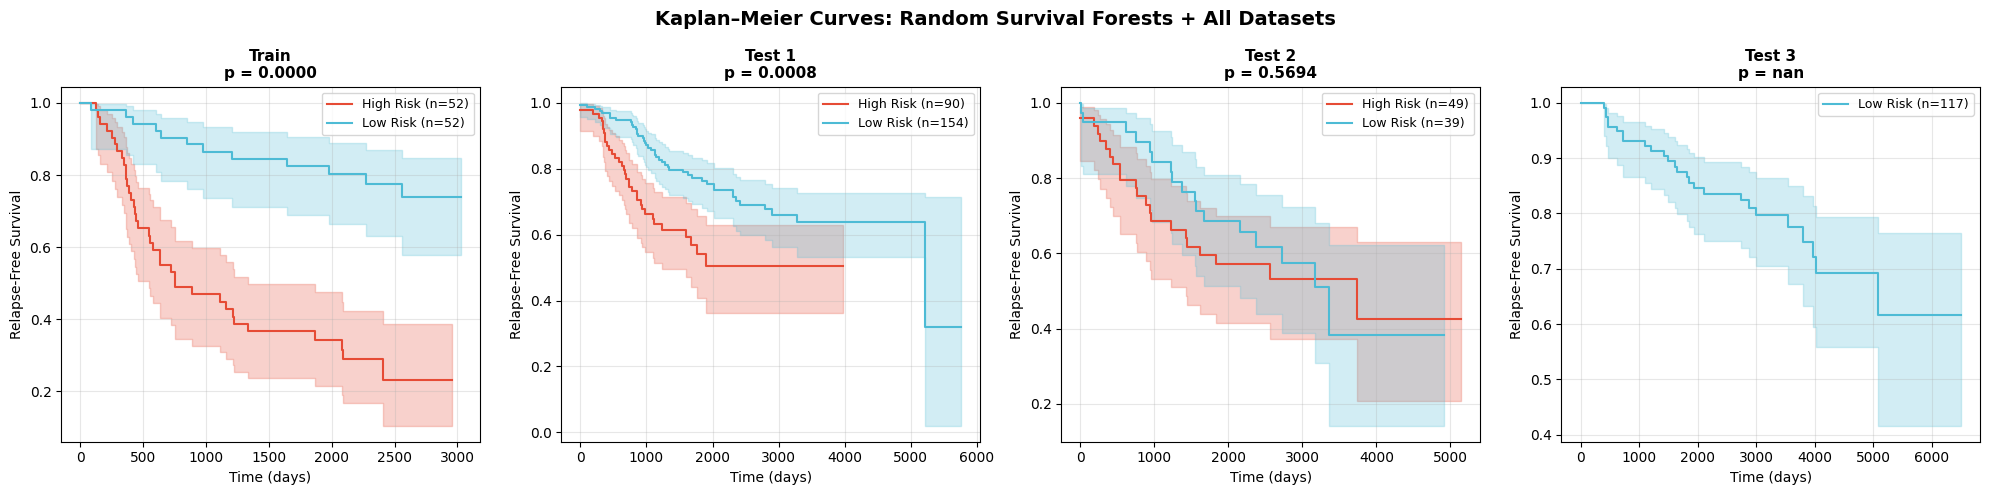

In [11]:
# Cutoff: median of training risk scores
train_median = np.median(rsf_risk_train)
print(f"Training median risk score (cutoff): {train_median:.4f}")

def stratify(scores):
    return np.where(scores >= train_median, "High Risk", "Low Risk")

def plot_km(df, scores, title, ax):
    groups = stratify(scores)
    tmp = pd.DataFrame({
        "time":  pd.to_numeric(df["relapse_free_time"],  errors="coerce").astype(float),
        "event": pd.to_numeric(df["relapse_free_event"], errors="coerce").astype(bool),
        "group": groups,
    }).dropna(subset=["time", "event"])

    kmf = KaplanMeierFitter()
    colors = {"High Risk": "#E64B35", "Low Risk": "#4DBBD5"}
    for group, color in colors.items():
        mask = tmp["group"] == group
        if mask.sum() == 0:
            continue
        kmf.fit(tmp.loc[mask, "time"], tmp.loc[mask, "event"],
                label=f"{group} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    high = tmp["group"] == "High Risk"
    low  = tmp["group"] == "Low Risk"
    p = logrank_test(tmp.loc[high, "time"], tmp.loc[low, "time"],
                     tmp.loc[high, "event"], tmp.loc[low, "event"]).p_value

    ax.set_title(f"{title}\np = {p:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Relapse-Free Survival")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    return p


datasets = [
    ("Train",  train_data,     rsf_risk_train),
    ("Test 1", test_data_one,  rsf_risk_test_one),
    ("Test 2", test_data_two,  rsf_risk_test_two),
    ("Test 3", test_data_three,rsf_risk_test_three),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, df, scores) in zip(axes, datasets):
    groups = stratify(scores)
    p = plot_km(df, scores, name, ax)
    print(f"{name:8s} — high={np.sum(groups=='High Risk'):3d}  "
          f"low={np.sum(groups=='Low Risk'):3d}  log-rank p={p:.4f}")

plt.suptitle("Kaplan–Meier Curves: Random Survival Forests + All Datasets", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../../visuals/rsf_km_stratification.png", dpi=150, bbox_inches="tight")
print("\nSaved: rsf_km_stratification.png")
plt.show()

## Gene Signature Visualizations

Saved: rsf_gene_signature_heatmap.png


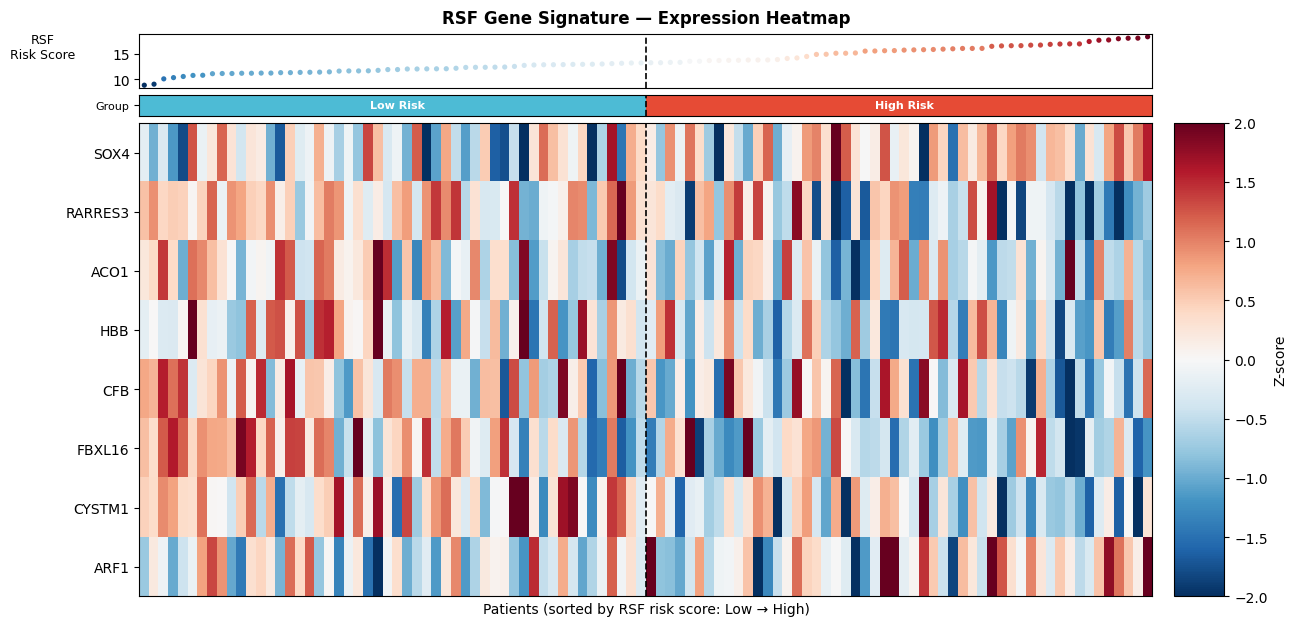

In [12]:
# Sort patients by RSF risk score (low → high)
vis_groups       = stratify(rsf_risk_train)
vis_group_series = pd.Series(vis_groups, index=train_data.index)

sort_idx      = np.argsort(rsf_risk_train)
sorted_scores = rsf_risk_train[sort_idx]
sorted_groups = vis_groups[sort_idx]

expr_mat  = train_data[sig_genes].values[sort_idx].T    # (n_genes, n_patients)
expr_z    = zscore(expr_mat, axis=1)
n_patients = expr_mat.shape[1]
split      = int(np.sum(sorted_groups == "Low Risk"))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 2.5 + len(sig_genes) * 0.6))
gs  = fig.add_gridspec(3, 2,
                       height_ratios=[0.9, 0.35, len(sig_genes)],
                       width_ratios=[20, 1],
                       hspace=0.04, wspace=0.04)

ax_rs = fig.add_subplot(gs[0, 0])
ax_rs.scatter(range(n_patients), sorted_scores,
              c=sorted_scores, cmap="RdBu_r", s=14, linewidths=0)
ax_rs.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_rs.set_ylabel("RSF\nRisk Score", fontsize=9, rotation=0, labelpad=50)
ax_rs.set_xlim(-0.5, n_patients - 0.5)
ax_rs.set_xticks([])
ax_rs.set_title("RSF Gene Signature — Expression Heatmap", fontsize=12, fontweight="bold", pad=8)

ax_grp = fig.add_subplot(gs[1, 0], sharex=ax_rs)
ax_grp.imshow(np.where(sorted_groups == "High Risk", 1, 0).reshape(1, -1),
              aspect="auto", cmap=ListedColormap(["#4DBBD5", "#E64B35"]), vmin=0, vmax=1)
ax_grp.set_yticks([0])
ax_grp.set_yticklabels(["Group"], fontsize=8)
ax_grp.set_xticks([])
ax_grp.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_grp.text(split / 2, 0, "Low Risk",  ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax_grp.text(split + (n_patients - split) / 2, 0, "High Risk", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax_hm = fig.add_subplot(gs[2, 0], sharex=ax_rs)
im = ax_hm.imshow(expr_z, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax_hm.set_yticks(range(len(sig_genes)))
ax_hm.set_yticklabels(sig_genes, fontsize=10)
ax_hm.set_xlabel("Patients (sorted by RSF risk score: Low → High)", fontsize=10)
ax_hm.axvline(split - 0.5, color="black", lw=1.2, ls="--")

plt.colorbar(im, cax=fig.add_subplot(gs[2, 1]), label="Z-score")
plt.savefig("../../visuals/rsf_gene_signature_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: rsf_gene_signature_heatmap.png")
plt.show()

Saved: rsf_gene_signature_expression.png


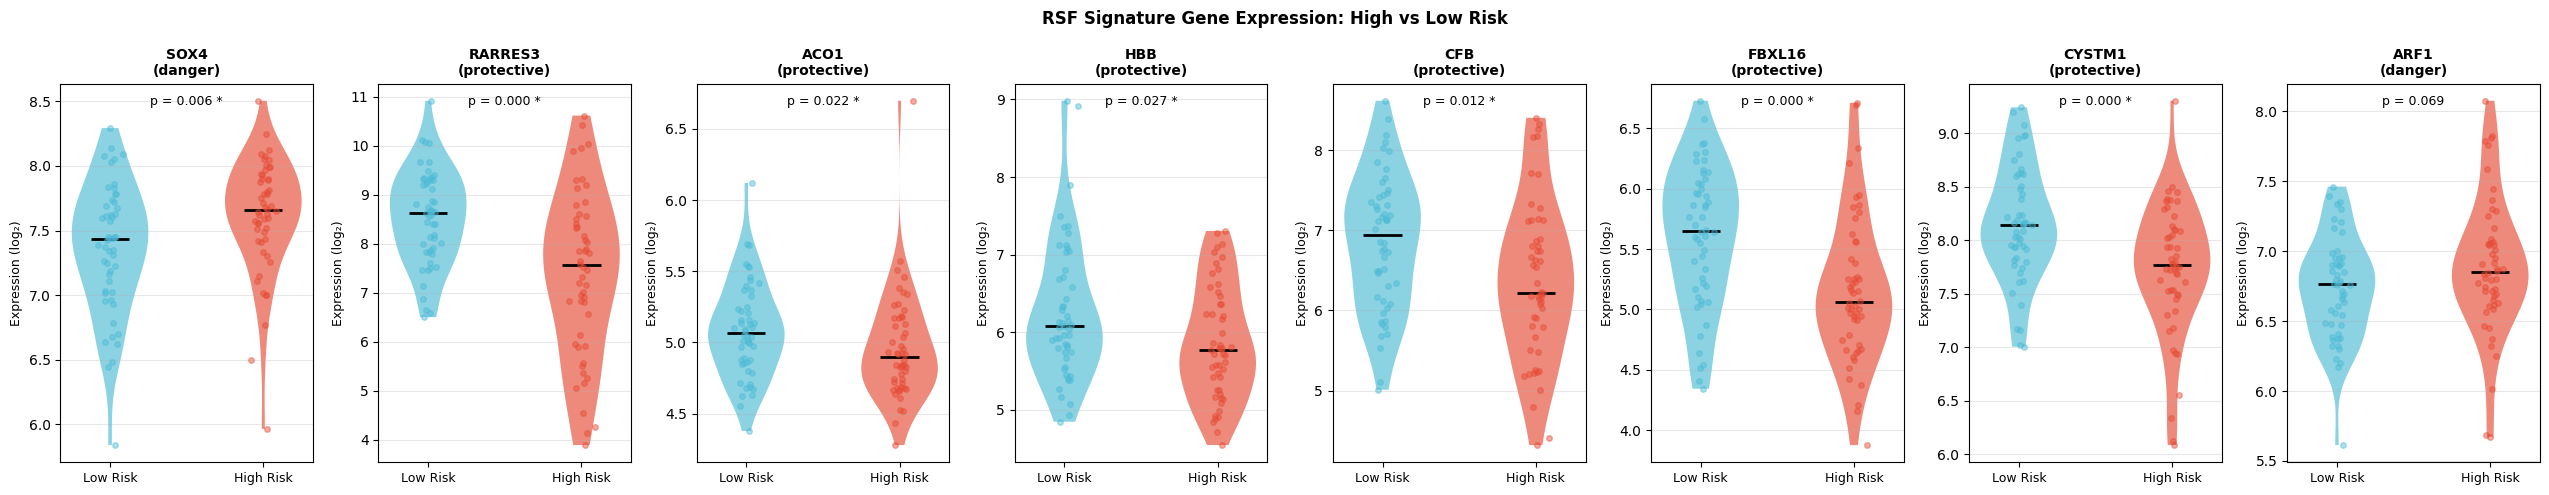

In [13]:
# ── Violin plots: sig gene expression in high vs low risk ─────────────────────
# Use numpy boolean masks (vis_groups) to avoid pandas index alignment issues
mask_low  = (vis_groups == "Low Risk")
mask_high = (vis_groups == "High Risk")

n_genes = len(sig_genes)
fig, axes = plt.subplots(1, n_genes, figsize=(max(6, 3.2 * n_genes), 5))
if n_genes == 1:
    axes = [axes]

for ax, gene in zip(axes, sig_genes):
    data_low  = train_data[gene].values[mask_low]
    data_high = train_data[gene].values[mask_high]

    if len(data_low) < 2 or len(data_high) < 2:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                transform=ax.transAxes, fontsize=9)
        ax.set_title(gene, fontsize=10, fontweight="bold")
        continue

    parts = ax.violinplot([data_low, data_high], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], ["#4DBBD5", "#E64B35"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    for pos, data, color in [(0, data_low, "#4DBBD5"), (1, data_high, "#E64B35")]:
        jitter = np.random.default_rng(42).normal(0, 0.04, len(data))
        ax.scatter(pos + jitter, data, alpha=0.45, s=16, color=color, zorder=3)

    _, p = mannwhitneyu(data_low, data_high, alternative="two-sided")
    role = sig_genes_df.loc[sig_genes_df["gene"] == gene, "role"].values[0]
    ax.text(0.5, 0.97, f"p = {p:.3f}" + (" *" if p < 0.05 else ""),
            transform=ax.transAxes, ha="center", va="top", fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low Risk", "High Risk"], fontsize=9)
    ax.set_title(f"{gene}\n({role})", fontsize=10, fontweight="bold")
    ax.set_ylabel("Expression (log₂)", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("RSF Signature Gene Expression: High vs Low Risk", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../visuals/rsf_gene_signature_expression.png", dpi=150, bbox_inches="tight")
print("Saved: rsf_gene_signature_expression.png")
plt.show()

Saved: rsf_gene_signature_correlation.png


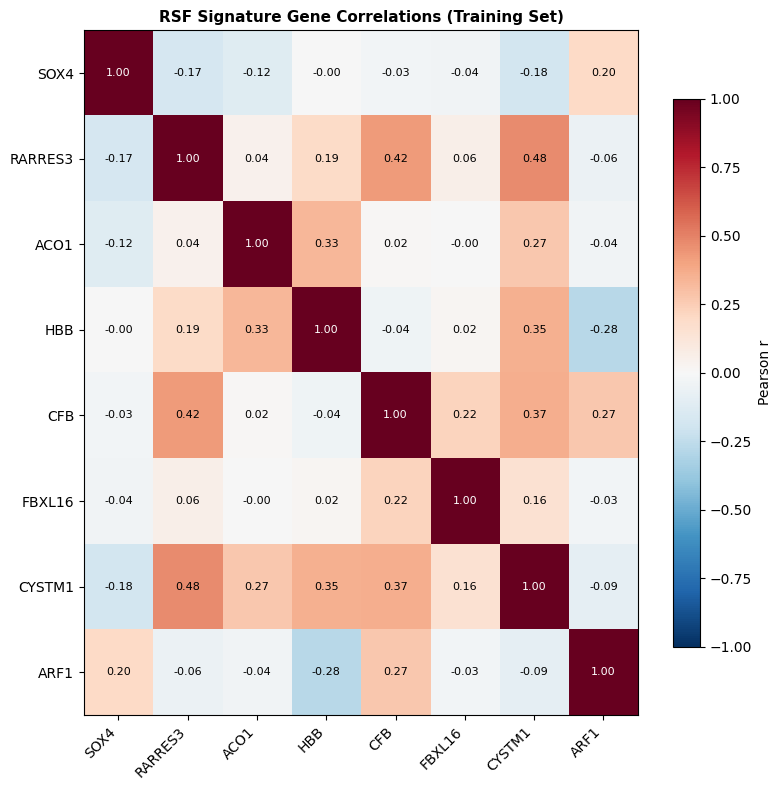

In [14]:
# ── Correlation heatmap between sig genes ─────────────────────────────────────
if len(sig_genes) > 1:
    corr = train_data[sig_genes].corr(method="pearson")

    fig, ax = plt.subplots(figsize=(max(4, len(sig_genes)), max(3.5, len(sig_genes))))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(sig_genes)))
    ax.set_yticks(range(len(sig_genes)))
    ax.set_xticklabels(sig_genes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(sig_genes, fontsize=10)

    for i in range(len(sig_genes)):
        for j in range(len(sig_genes)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.6 else "black")

    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
    ax.set_title("RSF Signature Gene Correlations (Training Set)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../../visuals/rsf_gene_signature_correlation.png", dpi=150, bbox_inches="tight")
    print("Saved: rsf_gene_signature_correlation.png")
    plt.show()
else:
    print("Only 1 significant gene — correlation heatmap skipped.")